In [1]:
indir='/home/hsher/scratch/circSTAMP_pipe/output/sailor'


In [2]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
def edit_level(df, pval_thres = 10e-6):
    ''' find the number of significant edit events'''
    #df[['n_edit', 'n_cov']]=df['detail'].str.split(',', expand = True).applymap(lambda i: int(i))
    #df['frac_edit']=df['n_edit']/df['n_cov']
    #df.plot.scatter(x = 'frac_edit', y = 'confidence_score')
    return df.loc[df['confidence_score']>(1-pval_thres)].shape[0]

In [4]:
suffix = '.Aligned.sortedByCoord.out.bam.combined.readfiltered.formatted.varfiltered.snpfiltered.ranked.bed'
all_files = [f.replace(suffix, '') for f in os.listdir(indir) if f.endswith(suffix)]

In [5]:
all_files

['HuR-50-R',
 'APO-1-A',
 'HuR-1-R',
 'APO-noD-R',
 'APO-50-R',
 'HuR-noD-A',
 'APO-noD-A',
 'APO-50-A',
 'HuR-noD-R',
 'HuR-50-A',
 'APO-1-R',
 'HuR-1-A']

In [6]:
pthres = [1e-6, 1e-5, 1e-4, 1e-3]
all_data = []
for f in all_files:
    df = pd.read_csv(os.path.join(indir, f+suffix), sep = '\t', 
                     names = ['chrom', 'start', 'end', 'confidence_score', 'detail', 'strand'])
    data = []
    for pthre in pthres:
        n_sig = edit_level(df, pval_thres = pthre)
        data.append(n_sig)
    
    all_data.append(data)

In [7]:
sig_edit_count = pd.DataFrame(all_data, columns = pthres, index = all_files)

In [8]:
sig_edit_count['color'] = pd.Series(sig_edit_count.index).apply(
    lambda x: 'grey' if 'noD' in x else 'salmon' if '50' in x else 'darkred').tolist()

/home/hsher/miniconda3/envs/Metadensity/lib/python3.7/site-packages/pandas/plotting/_matplotlib/tools.py:331: MatplotlibDeprecationWarning: 
The is_first_col function was deprecated in Matplotlib 3.4 and will be removed two minor releases later. Use ax.get_subplotspec().is_first_col() instead.
  if ax.is_first_col():
/home/hsher/miniconda3/envs/Metadensity/lib/python3.7/site-packages/pandas/plotting/_matplotlib/tools.py:331: MatplotlibDeprecationWarning: 
The is_first_col function was deprecated in Matplotlib 3.4 and will be removed two minor releases later. Use ax.get_subplotspec().is_first_col() instead.
  if ax.is_first_col():
/home/hsher/miniconda3/envs/Metadensity/lib/python3.7/site-packages/pandas/plotting/_matplotlib/tools.py:331: MatplotlibDeprecationWarning: 
The is_first_col function was deprecated in Matplotlib 3.4 and will be removed two minor releases later. Use ax.get_subplotspec().is_first_col() instead.
  if ax.is_first_col():
/home/hsher/miniconda3/envs/Metadensity/lib

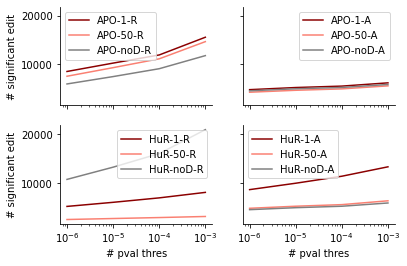

In [9]:
f, ax = plt.subplots(2,2, sharex = True, sharey = True)
for i,group in enumerate(['APO', 'HuR']):
    for j,enrich in enumerate(['-R', '-A']):
        sub = sig_edit_count.loc[(sig_edit_count.index.str.contains(group))&
                           (sig_edit_count.index.str.contains(enrich))

                           ].sort_index()
        sub[pthres].T.plot(color = sub['color'], ax = ax[i,j])
        ax[i,j].set_xscale('log')
        ax[i,j].set_ylabel('# significant edit')
        ax[i,j].set_xlabel('# pval thres')
sns.despine()

In [10]:
sig_edit_count.sort_index()

,1e-06,1e-05,0.0001,0.001,color
APO-1-A,4855,5290,5581,6245,darkred
APO-1-R,8570,10282,11947,15567,darkred
APO-50-A,4329,4728,5012,5630,salmon
APO-50-R,7596,9351,11156,14669,salmon
APO-noD-A,4618,5040,5307,5910,grey
APO-noD-R,6020,7527,9136,11809,grey
HuR-1-A,8663,9972,11402,13325,darkred
HuR-1-R,5233,6070,6978,8100,darkred
HuR-50-A,4851,5273,5598,6380,salmon
HuR-50-R,2557,2757,2956,3175,salmon
